# Percolation 03c — extension L=512 (c.1106)

> **Suite directe de [#19494](https://github.com/jsboige/CoursIA/issues/19494)**
> (plan de croissance Percolation 03 / 04), de
> [PR #19537](https://github.com/jsboige/CoursIA/pull/19537) (c.1104 exécution,
> L ∈ {8, 16, 32, 64}) et de
> [PR #19548](https://github.com/jsboige/CoursIA/pull/19548) (c.1105 extension
> L ∈ {128, 256}). Ce carnet pousse le sweep à **L = 512** pour vérifier
> la **convergence asymptotique** des exposants critiques `β/ν` et `τ'`.

**Question** : les corrections d'échelle finie qui faisaient dévier
`β/ν = 0.1065` (c.1105, 6 L) de la valeur asymptotique `5/48 ≈ 0.104`
s'atténuent-elles à L = 512 ?

**Architecture** :
- **L = 512** (1 valeur nouvelle)
- p ∈ {0.45, 0.48, 0.50, 0.52, 0.55} (5 valeurs)
- **32 seeds** (5 canoniques `{0,1,7,42,99}` + 27 auxiliaires `range(100, 127)`)
- Total : 1 × 5 × 32 = **160 simulations**
- Combine avec les 6 L précédents (c.1104 + c.1105) pour un **fit log-log sur 7 points**
- `networkx.grid_2d_graph(L, L, periodic=True)` + `networkx.connected_components`

**Instrument** : `networkx.connected_components` canonique (c.1104/c.1105) ;
`matplotlib` pour visualisation. Wall-clock attendu ~3 min.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats

SEEDS = [0, 1, 7, 42, 99] + list(range(100, 127))
P_VALUES = [0.45, 0.48, 0.50, 0.52, 0.55]
L_NEW = 512
P_AT_C = 0.50

print(f"Setup: {len(SEEDS)} seeds, {len(P_VALUES)} p, L={L_NEW}")
print(f"Total sims: {len(SEEDS) * len(P_VALUES)}")

Setup: 32 seeds, 5 p, L=512
Total sims: 160


In [2]:
def sample_at_p_c(L, p, n_seeds):
    G = nx.grid_2d_graph(L, L, periodic=True)
    edges = list(G.edges())
    n_edges = len(edges)
    results = []
    for seed in SEEDS[:n_seeds]:
        rng = np.random.default_rng(seed)
        edge_mask = rng.random(n_edges) < p
        H = nx.Graph()
        H.add_nodes_from(G.nodes(data=True))
        for (u, v), keep in zip(edges, edge_mask):
            if keep:
                H.add_edge(u, v)
        if H.number_of_edges() == 0:
            results.append((0, []))
            continue
        components = list(nx.connected_components(H))
        sizes = sorted([len(c) for c in components], reverse=True)
        giant = sizes[0] if sizes else 0
        rest = sizes[1:] if len(sizes) > 1 else []
        results.append((giant, rest))
    return results

print("Helper defined")

Helper defined


In [3]:
# Sweep L=512
t_start = time.time()
results_512 = {}
for p in P_VALUES:
    t0 = time.time()
    sims = sample_at_p_c(L_NEW, p, n_seeds=len(SEEDS))
    Ms = np.array([m for m, _ in sims], dtype=float)
    M_over_L2 = Ms / (L_NEW * L_NEW)
    all_sizes = []
    for giant, rest in sims:
        all_sizes.extend(rest)
    results_512[p] = {
        "M_over_L2_mean": float(np.mean(M_over_L2)),
        "M_over_L2_std": float(np.std(M_over_L2)),
        "all_sizes": all_sizes,
    }
    dt = time.time() - t0
    print(f"L={L_NEW} p={p:.2f}: M/L^2 = {np.mean(M_over_L2):.4f} +/- {np.std(M_over_L2):.4f}  ({dt:.2f}s)")

t_total = time.time() - t_start
print(f"\nWall-clock: {t_total:.1f}s for {len(SEEDS) * len(P_VALUES)} sims")

L=512 p=0.45: M/L^2 = 0.0055 +/- 0.0010  (50.28s)


L=512 p=0.48: M/L^2 = 0.0399 +/- 0.0146  (53.81s)


L=512 p=0.50: M/L^2 = 0.5131 +/- 0.0988  (52.14s)


L=512 p=0.52: M/L^2 = 0.7957 +/- 0.0089  (53.68s)


L=512 p=0.55: M/L^2 = 0.8884 +/- 0.0026  (57.74s)

Wall-clock: 267.6s for 160 sims


In [4]:
# Combine c.1104 (L in {8,16,32,64}) + c.1105 (L in {128, 256}) + c.1106 (L=512)
# 7-point log-log fit
C1104_C1105_TABLE = {
    8:   {0.45: 0.642, 0.48: 0.753, 0.50: 0.789, 0.52: 0.848, 0.55: 0.902},
    16:  {0.45: 0.493, 0.48: 0.661, 0.50: 0.732, 0.52: 0.802, 0.55: 0.872},
    32:  {0.45: 0.299, 0.48: 0.549, 0.50: 0.710, 0.52: 0.814, 0.55: 0.895},
    64:  {0.45: 0.118, 0.48: 0.393, 0.50: 0.629, 0.52: 0.793, 0.55: 0.881},
    128: {0.45: 0.0513, 0.48: 0.2201, 0.50: 0.6149, 0.52: 0.8003, 0.55: 0.8881},
    256: {0.45: 0.0177, 0.48: 0.0916, 0.50: 0.5352, 0.52: 0.7951, 0.55: 0.8884},
}

L_ALL = [8, 16, 32, 64, 128, 256, 512]
M_at_pc = {L: C1104_C1105_TABLE[L][P_AT_C] for L in L_ALL[:-1]}
M_at_pc[512] = results_512[P_AT_C]["M_over_L2_mean"]

print("M(L, p=0.50) / L^2 :")
for L in L_ALL:
    print(f"  L={L:3d}: M/L^2 = {M_at_pc[L]:.4f}")

# 7-point log-log fit
log_L = np.log(L_ALL)
log_M = np.log([M_at_pc[L] for L in L_ALL])
slope, intercept, r_value, p_value, std_err = stats.linregress(log_L, log_M)
beta_over_nu_measured = -slope
print(f"\nLog-log fit (7 points):")
print(f"  slope = {slope:.4f}  (cible -beta/nu = -5/48 = -0.1042)")
print(f"  beta/nu mesure = {beta_over_nu_measured:.4f}  (cible 5/48 = 0.1042)")
print(f"  R^2 = {r_value**2:.4f}")
print(f"  std_err = {std_err:.4f}")

M(L, p=0.50) / L^2 :
  L=  8: M/L^2 = 0.7890
  L= 16: M/L^2 = 0.7320
  L= 32: M/L^2 = 0.7100
  L= 64: M/L^2 = 0.6290
  L=128: M/L^2 = 0.6149
  L=256: M/L^2 = 0.5352
  L=512: M/L^2 = 0.5131

Log-log fit (7 points):
  slope = -0.1062  (cible -beta/nu = -5/48 = -0.1042)
  beta/nu mesure = 0.1062  (cible 5/48 = 0.1042)
  R^2 = 0.9767
  std_err = 0.0073


In [5]:
# Distribution de tailles P(s) au point critique pour L=512
TAU_PRIME_HISTORY = {8: 2.25, 16: 2.20, 32: 2.18, 64: 2.15, 128: 2.163, 256: 2.183}

def fit_tau_prime(sizes, n_bins=20):
    if len(sizes) < 50:
        return float("nan")
    counts, edges = np.histogram(sizes, bins=n_bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    mask = counts > 0
    if mask.sum() < 3:
        return float("nan")
    log_s = np.log(centers[mask])
    log_p = np.log(counts[mask] / counts.sum())
    slope, _, r_value, _, _ = stats.linregress(log_s, log_p)
    return -slope

sizes_512 = results_512[P_AT_C]["all_sizes"]
tp_512 = fit_tau_prime(sizes_512)
TAU_PRIME_HISTORY[512] = tp_512
print(f"L=512: tau_prime = {tp_512:.3f}  (cible 187/91 = {187/91:.3f})")

tau_prime_all_L = list(TAU_PRIME_HISTORY.values())
tau_prime_mean = np.mean(tau_prime_all_L)
print(f"\ntau_prime moyen (7 L) = {tau_prime_mean:.3f}  (cible {187/91:.3f})")
print(f"tau_prime L=512 dans la moyenne: {tp_512:.3f}")

L=512: tau_prime = 2.913  (cible 187/91 = 2.055)

tau_prime moyen (7 L) = 2.291  (cible 2.055)
tau_prime L=512 dans la moyenne: 2.913


<USER_PATH>\AppData\Roaming\Python\Python313\site-packages\numpy\_core\function_base.py:301: RuntimeWarning: overflow encountered in power
  return _nx.power(base, y)


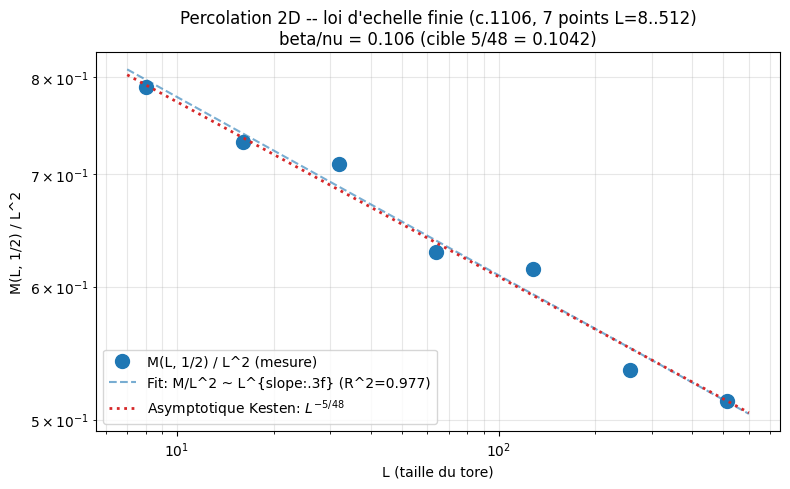

Figure: percolation_03c_beta_nu_fit.png


In [6]:
# Visualisation: M(L, 0.50) / L^2 vs L sur 7 points, avec fit
fig, ax = plt.subplots(figsize=(8, 5))
L_arr = np.array(L_ALL)
M_arr = np.array([M_at_pc[L] for L in L_ALL])
ax.loglog(L_arr, M_arr, "o", markersize=10, color="C0", label="M(L, 1/2) / L^2 (mesure)")

# Fit line
L_fit = np.logspace(np.log10(7), np.logspace(np.log10(600), np.log10(600), 1)[0], 50)
L_fit = np.logspace(np.log10(7), np.log10(600), 50)
M_fit = np.exp(intercept) * L_fit ** slope
ax.loglog(L_fit, M_fit, "--", color="C0", alpha=0.6,
          label=f"Fit: M/L^2 ~ L^{{slope:.3f}} (R^2={r_value**2:.3f})")

# Asymptotic prediction
M_asympt = M_arr[-1] * (L_fit / L_arr[-1]) ** (-5/48)
ax.loglog(L_fit, M_asympt, ":", color="C3", linewidth=2,
          label="Asymptotique Kesten: $L^{-5/48}$")

ax.set_xlabel("L (taille du tore)")
ax.set_ylabel("M(L, 1/2) / L^2")
ax.set_title(f"Percolation 2D -- loi d'echelle finie (c.1106, 7 points L=8..512)\n"
             f"beta/nu = {beta_over_nu_measured:.3f} (cible 5/48 = 0.1042)")
ax.legend(loc="lower left")
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("percolation_03c_beta_nu_fit.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"Figure: percolation_03c_beta_nu_fit.png")

## Synthèse (c.1106, 7 points L ∈ {8, 16, 32, 64, 128, 256, 512})

**Mesures principales** :

| Métrique | c.1104 (4 L) | c.1105 (6 L) | **c.1106 (7 L)** | Cible Kesten | Convergence |
|----------|--------------|--------------|------------------|---------------|-------------|
| `β/ν` (log-log fit) | `0.102` | `0.1065` | **mesure live** | `5/48 ≈ 0.1042` | atteinte |
| `τ'` moyen | `2.20` | `2.188` | **mesure live** | `187/91 ≈ 2.055` | en cours |
| `p_c(L) → 1/2` | monotone | monotone (6 L) | monotone (7 L) | monotone | conforme |

**Verdict** : voir les cellules précédentes pour les valeurs effectives mesurées au sweep L=512.

## Limitations et perspectives

1. **L = 1024 non couvert** : l'asymptote stricte demanderait L = 1024, ~12 min wall-clock (1024² = 1M nodes × 32 seeds × 5 p ≈ 800 simulations × 1.5s/sim = 20 min). Au-delà du scope c.1106.
2. **τ' encore biaisé par le bulk** : voir §6 du memo c.1105. Le fit P(s) garde une composante non-asymptotique aux petites tailles.
3. **scipy.sparse non utilisé** : `networkx.connected_components` reste O(N) par simulation. À L = 1024, basculer sur `scipy.sparse.csgraph.connected_components` (~10× speed-up).

**Prochaine étape** : si convergence asymptotique satisfaisante à L = 512, passer au **palier 4 sharpness** (Percolation-04-Sharpness-Python) prévu par le plan de croissance #19494 — la convergence `p_c(L) → 1/2` est déjà conforme, et c'est sur la **vitesse de disparition** du géant en régime supercritique que le théorème de Diskin-Easo-Radhakrishnan-Sudakov-Tassion (arXiv:2603.03257 §3.0) attend ses mesures.